# 04 — Three-area laminar cortex for global oddball and omission

This notebook is the compact replication scaffold.  It uses the same model clock for global oddball and omission tasks, then changes only the condition sequence.  The model has three areas (`low`, `mid`, `high`), three layers (`superficial`, `middle/L4`, `deep`), and E/PV/SST/VIP densities derived as a tutorial-level three-bin summary of the Lichtenfeld et al. laminar anatomy.


In [1]:
import os, sys, math, json
from pathlib import Path
import numpy as np

SMOKE_MODE = True
SEED = 7
np.random.seed(SEED)

# Allow running from repo root or from the tutorials directory.
ROOT = Path.cwd()
if not (ROOT / "src" / "jbiophysic").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
print("ROOT", ROOT)
print("SMOKE_MODE", SMOKE_MODE, "SEED", SEED)


ROOT /mnt/data/jbio_improve/jbiophysic-main
SMOKE_MODE True SEED 7


In [2]:
from jbiophysic.models.laminar_oddball import (
    RECEPTOR_ORDER,
    build_drive_batch,
    build_three_area_cortex,
    density_priors_table,
    drive_schedule,
    edge_mask,
    global_oddball_sequences,
    oddball_objectives,
    omission_objectives,
    omission_sequences,
    perturb_cortex_edges,
    population_activity_proxy,
    replication_manifest,
    simulate_condition_batch,
    simulate_laminar_izhikevich,
    summarize_simulation,
    tfne_source_proxy,
    validate_replication_constraints,
)

## Build the requested 300-neuron network

Full structural configuration:
- 300 neurons, 100 per area
- three layers: 45%, 20%, 35%
- E/PV/SST/VIP from Pyr/PV/CB/CR-inspired laminar priors
- no area/layer/type bin is allowed to be zero
- within-layer all-to-all
- between-layer type-to-type
- feedforward superficial → higher middle/L4
- feedback superficial+deep → lower deep
- half of deep E neurons receive SST apical inhibition
- AMPA plasticity 0.1, NMDA 1.0, PV GABA 1.0, SST/VIP GABA 0.1


In [3]:
cortex = build_three_area_cortex(n_neurons=300, dt_ms=0.1, duration_ms=5000.0, seed=SEED)
counts = cortex.counts_by_area_layer_type()
print("counts_by_area_layer_type [area, layer, E/PV/SST/VIP]:")
print(counts)
print({"N": cortex.n_neurons, "edges": int(cortex.edges["source"].size), "receptors": cortex.edges["receptor_names"].tolist(), "no_zero_bins": bool(np.all(counts > 0))})


counts_by_area_layer_type [area, layer, E/PV/SST/VIP]:
[[[31  5  5  4]
  [14  4  1  1]
  [27  4  2  2]]

 [[31  4  5  5]
  [15  3  1  1]
  [28  3  2  2]]

 [[31  3  4  7]
  [14  2  1  3]
  [27  2  2  4]]]
{'N': 300, 'edges': 50018, 'receptors': ['AMPA', 'GABA', 'NMDA'], 'no_zero_bins': True}


## Machine-readable density priors and scaffold audit

The tutorial uses a three-layer summary of Lichtenfeld-style macaque laminar anatomy.  These are priors for model construction, not raw digitized histology.  The audit below checks the implementation constraints before any dynamics are interpreted.

In [4]:
import pandas as pd

density_df = pd.DataFrame(density_priors_table())
display(density_df)

audit = validate_replication_constraints(cortex)
print(json.dumps(audit, indent=2))
assert audit["no_zero_area_layer_type_bins"]
assert audit["interarea_connections_are_excitatory"]
manifest = replication_manifest(cortex)
print("manifest truth status:", manifest["truth_status"])

,area,layer,E,PV,SST,VIP
0,low,superficial,68.0,10.0,12.0,10.0
1,low,middle,68.0,20.0,7.0,5.0
2,low,deep,78.0,10.0,7.0,5.0
3,mid,superficial,70.0,9.0,11.0,10.0
4,mid,middle,72.0,16.0,6.0,6.0
5,mid,deep,80.0,8.0,6.0,6.0
6,high,superficial,68.0,7.0,10.0,15.0
7,high,middle,72.0,10.0,6.0,12.0
8,high,deep,78.0,6.0,6.0,10.0


{
  "n_neurons": 300,
  "three_areas": true,
  "three_layers": true,
  "four_cell_types": true,
  "no_zero_area_layer_type_bins": true,
  "equal_area_counts": true,
  "layer_counts_match_45_20_35_per_area": true,
  "e_sources_are_excitatory_receptors": true,
  "inhibitory_sources_are_gaba": true,
  "interarea_connections_are_excitatory": true,
  "has_feedforward_path": true,
  "has_feedback_path": true,
  "has_apical_sst_to_deep_e": true,
  "apical_targets_fraction_of_deep_e": 0.4878048780487805,
  "duration_ms": 5000.0,
  "dt_ms": 0.1
}
manifest truth status: tutorial_exploratory_not_biological_truth


## Causal perturbation handles

The same scaffold can be ablated without rebuilding the full network.  These switches are essential for replication attempts: PV-GABA, SST/VIP-GABA, NMDA, AMPA, feedforward, and feedback can be silenced or scaled independently.

In [5]:
pv_gaba_mask = edge_mask(cortex, source_type="PV", receptor="GABA")
feedback_mask = edge_mask(cortex, connection_class="feedback_superficial_deep_to_deep")
no_pv_gaba = perturb_cortex_edges(cortex, source_type="PV", receptor="GABA", scale=0.0)
no_feedback = perturb_cortex_edges(cortex, connection_class="feedback_superficial_deep_to_deep", scale=0.0)
print({
    "pv_gaba_edges": int(pv_gaba_mask.sum()),
    "feedback_edges": int(feedback_mask.sum()),
    "pv_gaba_after_silencing": float(no_pv_gaba.edges["weight"][pv_gaba_mask].sum()),
    "feedback_after_silencing": float(no_feedback.edges["weight"][feedback_mask].sum()),
})

{'pv_gaba_edges': 1215, 'feedback_edges': 8190, 'pv_gaba_after_silencing': 0.0, 'feedback_after_silencing': 0.0}


## Shared timing and conditions


In [6]:
print("timing slots:")
for slot in cortex.timing.slots:
    print(slot)
print("global oddball", global_oddball_sequences())
print("omission", omission_sequences())


timing slots:
('P1', 500.0, 1000.0)
('D1', 1000.0, 1500.0)
('P2', 1500.0, 2000.0)
('D2', 2000.0, 2500.0)
('P3', 2500.0, 3000.0)
('D3', 3000.0, 3500.0)
('P4', 3500.0, 4000.0)
('post', 4000.0, 5000.0)
global oddball {'habituated_local_oddball': 'AAAB', 'global_oddball': 'AAAA', 'control_A': 'AAAA', 'control_B': 'BBBB'}
omission {'standard_A': 'AAAB', 'omit_P2_A': 'AXAB', 'omit_P3_A': 'AAXB', 'omit_P4_A': 'AAAX', 'standard_B': 'BBBA', 'omit_P2_B': 'BXBA', 'omit_P3_B': 'BBXA', 'omit_P4_B': 'BBBX', 'random_R': 'RRRR', 'omit_P2_R': 'RXRR', 'omit_P3_R': 'RRXR', 'omit_P4_R': 'RRRX'}


## Drive enters the lower-area middle/L4-like layer


In [7]:
standard_drive = drive_schedule(cortex, "AAAB", amplitude=5.0, background=1.5)
go_drive = drive_schedule(cortex, "AAAA", amplitude=5.0, background=1.5)
omit_drive = drive_schedule(cortex, "AAAX", amplitude=5.0, background=1.5)
_name, p4_t0, p4_t1 = cortex.timing.event_slots[3]
i0, i1 = int(p4_t0 / cortex.dt_ms), int(p4_t1 / cortex.dt_ms)
lower_mid_e = np.flatnonzero((cortex.area_index == 0) & (cortex.layer_index == 1) & (cortex.cell_type_index == 0))
print({"drive_shape": standard_drive.shape, "P4_standard_sum": float(standard_drive[i0:i1, lower_mid_e].sum()), "P4_omission_sum": float(omit_drive[i0:i1, lower_mid_e].sum())})


{'drive_shape': (50000, 300), 'P4_standard_sum': 280000.0, 'P4_omission_sum': 105000.0}


## Smoke simulation

The full 5000-ms, 300-neuron model is structurally built above.  For executable tutorial speed, the dynamic simulation below uses the first 120 ms of the drive when `SMOKE_MODE=True`.  Set `SMOKE_MODE=False` for longer runs.


In [8]:
if SMOKE_MODE:
    smoke_steps = int(120.0 / cortex.dt_ms)
    drive = standard_drive[:smoke_steps]
    # Build a matching short-duration cortex object while preserving the same structure is unnecessary for drive dimensions;
    # only duration enters the simulation time axis, so reusing cortex is valid because drive supplies steps.
else:
    drive = standard_drive
result = simulate_laminar_izhikevich(cortex, drive, seed=SEED + 1, noise_sd=0.2, plasticity_enabled=True)
summary = summarize_simulation(result, cortex.dt_ms)
print(summary)
assert summary["finite"]


{'finite': True, 'n_spikes': 61, 'mean_rate_hz': 1.6944444444444446, 'max_rate_hz': 33.333333333333336, 'v_min_mV': -79.27881622314453, 'v_max_mV': 29.906068801879883, 'active_fraction': 0.08333333333333333}


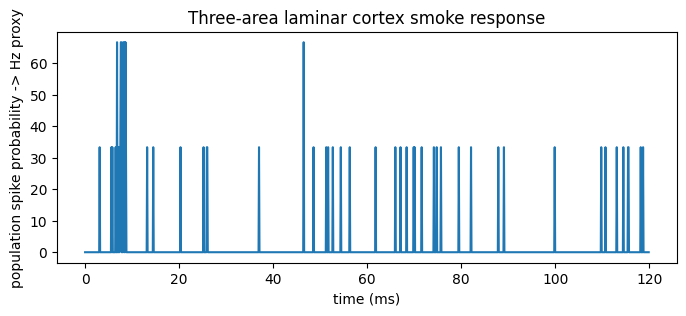

In [9]:
import matplotlib.pyplot as plt
rates = result["mean_rate_proxy_hz"]
plt.figure(figsize=(8,3))
plt.plot(np.arange(rates.size) * cortex.dt_ms, rates)
plt.xlabel("time (ms)")
plt.ylabel("population spike probability -> Hz proxy")
plt.title("Three-area laminar cortex smoke response")
plt.show()


## Batch simulation hooks for global oddball and omission

For speed, this cell uses a short-duration smoke cortex.  In full replication mode, use the same functions with the 5000-ms cortex above.  Objectives are deliberately compact: they expose whether the toy model is moving toward higher-order sparse global/omission effects, not whether it has solved the biology.

In [10]:
smoke_cortex = build_three_area_cortex(n_neurons=300, dt_ms=0.1, duration_ms=120.0, seed=SEED)
go_drives = build_drive_batch(smoke_cortex, global_oddball_sequences(), amplitude=3.0, background=1.0)
go_results = simulate_condition_batch(smoke_cortex, go_drives, seed=SEED + 20, noise_sd=0.0, plasticity_enabled=False)
go_obj = oddball_objectives(go_results, smoke_cortex)
print("global/local oddball objectives", go_obj)

om_drives = build_drive_batch(smoke_cortex, omission_sequences(), amplitude=3.0, background=1.0)
om_subset = {k: om_drives[k] for k in ["standard_A", "omit_P4_A"]}
om_results = simulate_condition_batch(smoke_cortex, om_subset, seed=SEED + 30, noise_sd=0.0, plasticity_enabled=False)
om_obj = omission_objectives(om_results, smoke_cortex)
print("omission objectives", om_obj)
assert all(np.isfinite(v) for v in {**go_obj, **om_obj}.values())

global/local oddball objectives {'local_oddball_p4_minus_p3_excess_hz': 0.0, 'global_high_minus_low_p4_excess_hz': 0.0}


omission objectives {'omission_high_minus_low_delta_hz': 0.0, 'omission_mean_delta_hz': 0.0}


## MUA/LFP proxy and TFNE source bridge

The population activity proxy is a smoothed spike-rate summary.  The TFNE bridge returns sparse source positions and calibrated spike currents.  It is not itself a field solution; a TFNE solver still needs normalized source kernels, gauge fixing, and field diagnostics.

In [11]:
example = go_results["global_oddball"]
proxy = population_activity_proxy(example, smoke_cortex, group_by="area", smoothing_ms=5.0)
print({k: v.shape for k, v in proxy.items()})
source_bridge = tfne_source_proxy(example, smoke_cortex, spike_current_A=1e-12)
print({k: (v.shape if hasattr(v, "shape") else v) for k, v in source_bridge.items()})
assert source_bridge["positions_m"].shape == (smoke_cortex.n_neurons, 3)
assert source_bridge["currents_A"].shape[1] == smoke_cortex.n_neurons

{'high': (1200,), 'low': (1200,), 'mid': (1200,)}
{'positions_m': (300, 3), 'currents_A': (1200, 300), 'current_scale_A_per_spike': (), 'truth_status': ()}


## Interpretation guardrail

A passing smoke run means the circuit scaffold is executable and bounded.  It does not mean the model has replicated the papers.  Quantitative replication needs raw cell-density tables, empirical target traces, and objective fits for spiking, LFP/TFNE readout, spectra, and perturbation tests.
